# EDA: S&P 500 daily series

> **Educational only — not financial advice.**

Series exploration for the `market-forecast` pipeline: level vs. returns,
stationarity (ADF test), and ACF/PACF of the differenced series. The goal is to
justify two modelling choices made in `src/market_forecast/`:

1. The **price level is non-stationary** (it trends / random-walks), so the ML
   model targets **returns** (a roughly stationary series) and ARIMA differences
   the level (`d=1`).
2. **Autocorrelation of returns is weak**, which is *why* the naive baseline is
   so hard to beat — the honest headline of this project.

In [1]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from market_forecast.data import load_series
from market_forecast.features import compute_returns

close = load_series()
returns = compute_returns(close).dropna()
close.tail()

date
2026-05-22    7473.47
2026-05-26    7519.12
2026-05-27    7520.36
2026-05-28    7563.63
2026-05-29    7580.06
Name: close, dtype: float64

## 1. Price level vs. daily returns

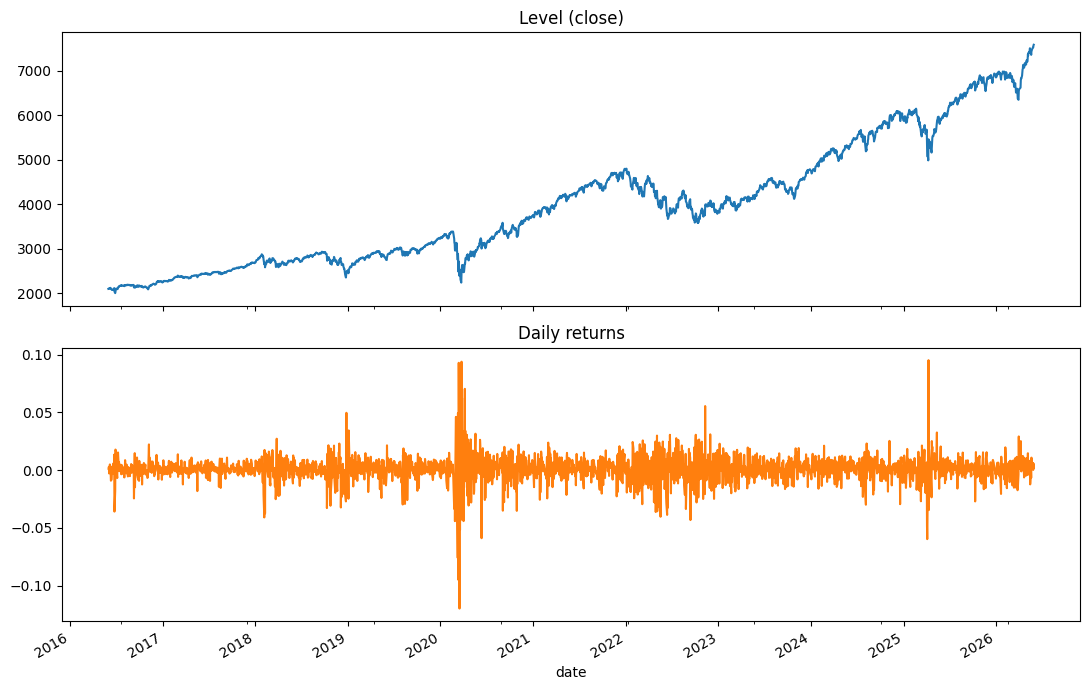

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
close.plot(ax=axes[0], title=f"Level ({close.name})")
returns.plot(ax=axes[1], title="Daily returns", color="tab:orange")
fig.tight_layout()

## 2. Stationarity (Augmented Dickey-Fuller)

A small p-value (< 0.05) rejects the unit-root null, i.e. the series looks
stationary. We expect the **level** to be non-stationary and **returns** to be
stationary.

In [3]:
def adf_report(series, label):
    stat, pvalue, *_ = adfuller(series.dropna())
    verdict = "stationary" if pvalue < 0.05 else "non-stationary"
    print(f"{label:<10} ADF stat={stat:8.3f}  p-value={pvalue:.4f}  -> {verdict}")


adf_report(close, "level")
adf_report(returns, "returns")

level      ADF stat=   0.935  p-value=0.9935  -> non-stationary
returns    ADF stat= -16.025  p-value=0.0000  -> stationary


## 3. ACF / PACF of returns

If returns were strongly autocorrelated, simple lag features would predict them
well. In practice the bars mostly sit inside the confidence band — weak,
short-lived structure — which is the core reason markets are close to a random
walk and the naive baseline is a tough benchmark.

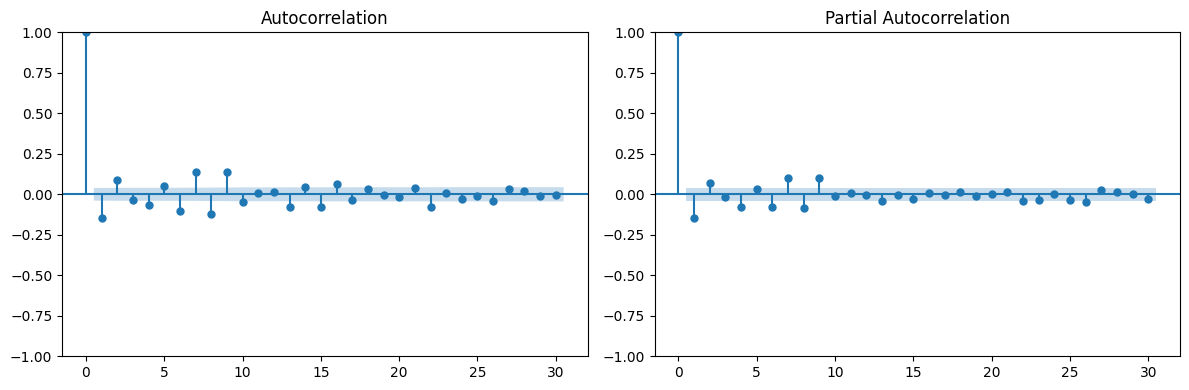

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns, lags=30, ax=axes[0])
plot_pacf(returns, lags=30, ax=axes[1], method="ywm")
fig.tight_layout()

## Takeaways

- Model **returns**, not the price level (stationarity + trees can't extrapolate
  levels).
- Expect only **marginal** gains over the naive baseline; report skill honestly.
- Validate with **walk-forward** splits (see `src/market_forecast/validate.py`),
  never a random split.